# Pathology Classification Results

## Objective
Evaluate pathology classification performance across harmonization methods,
using Leave-One-Site-Out (LOSO) cross-validation with a calibration strategy.

## Experiment Design
- **CV:** Leave-One-Site-Out (LOSO) with k=30 calibration normals
- **Models:** CatBoost, Logistic Regression
- **Harmonization methods:** raw, sitewise, combat, neurocombat, covbat
- **Features:** Manual (no scaler, no PCA)
- **Metrics:** AUC, MCC, Accuracy, Precision, Recall, F1

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

RESULTS_FILE = 'results/tables/newlabels/patho_clf_results.csv'
FIGURES_DIR  = 'results/figures/newlabels/03_harmonization'
TABLES_DIR   = 'results/tables/newlabels/03_harmonization'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

METHODS    = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
MODELS     = ['catboost', 'logreg']
METRICS    = ['auc', 'mcc', 'accuracy', 'f1-score']
COLOR_MAP  = {'raw': 'black', 'sitewise': 'tomato', 'combat': 'skyblue',
              'neurocombat': 'green', 'covbat': 'orange'}

def natural_sort_key(s):
    """Sort H1, H2, ..., H10, H11, ... naturally."""
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))]

In [3]:
df = pd.read_csv(RESULTS_FILE)
# Filter out k-calibration sweep rows (tag=k5/k15/k50) — keep only the headline §A run.
if 'tag' in df.columns:
    tag_str = df['tag'].astype(str)
    df = df[df['tag'].isna() | (tag_str == '') | (tag_str == 'nan') | tag_str.str.startswith('manual')]
print(f"Shape: {df.shape}")
print(f"Models: {df['model'].unique()}")
print(f"Methods: {df['method'].unique()}")
print(f"Hospitals: {df['hospital'].nunique()}")
df.head()

Shape: (300, 12)
Models: ['catboost' 'logreg']
Methods: ['raw' 'sitewise' 'combat' 'neurocombat' 'covbat']
Hospitals: 30


,accuracy,precision,recall,f1-score,auc,mcc,hospital,model,method,n_calib,n_test,tag
0,0.764434,0.533333,0.778761,0.633094,0.851300,0.486628,H25,catboost,raw,30,433,NaN
1,0.746173,0.588188,0.659510,0.621810,0.800670,0.433335,H1,catboost,raw,30,10452,NaN
2,0.754144,0.666667,0.772414,0.715655,0.854314,0.505378,H27,catboost,raw,30,362,NaN
3,0.766983,0.914388,0.775202,0.839062,0.824273,0.446860,H14,catboost,raw,30,1266,NaN
4,0.756098,0.787879,0.728972,0.757282,0.828533,0.514490,H29,catboost,raw,30,205,NaN


## Summary Table — Mean Metrics by Method and Model

In [4]:
summary = (
    df.groupby(['model', 'method'])[METRICS]
    .agg(['mean', 'std'])
    .round(4)
)
# Flatten column names
summary.columns = [f'{metric}_{stat}' for metric, stat in summary.columns]
summary = summary.reindex(pd.MultiIndex.from_product([MODELS, METHODS], names=['model', 'method']), fill_value=np.nan)
print(summary.to_string())

# Save
summary.to_csv(f'{TABLES_DIR}/patho_clf_summary.csv')
print(f"\nSaved to {TABLES_DIR}/patho_clf_summary.csv")

                      auc_mean  auc_std  mcc_mean  mcc_std  accuracy_mean  accuracy_std  f1-score_mean  f1-score_std
model    method                                                                                                     
catboost raw            0.8038   0.0484    0.4145   0.0996         0.7135        0.1016         0.6190        0.0913
         sitewise       0.8059   0.0506    0.4302   0.1041         0.7340        0.0767         0.6413        0.0853
         combat         0.8092   0.0521    0.4351   0.1095         0.7301        0.0875         0.6406        0.0807
         neurocombat    0.8093   0.0525    0.4351   0.1097         0.7317        0.0884         0.6396        0.0838
         covbat         0.7930   0.0526    0.4145   0.1068         0.7219        0.0819         0.6293        0.0809
logreg   raw            0.7705   0.0524    0.3741   0.0982         0.6949        0.0976         0.5923        0.0910
         sitewise       0.7686   0.0568    0.3740   0.0949      

## Heatmap — AUC and MCC (Model x Method)

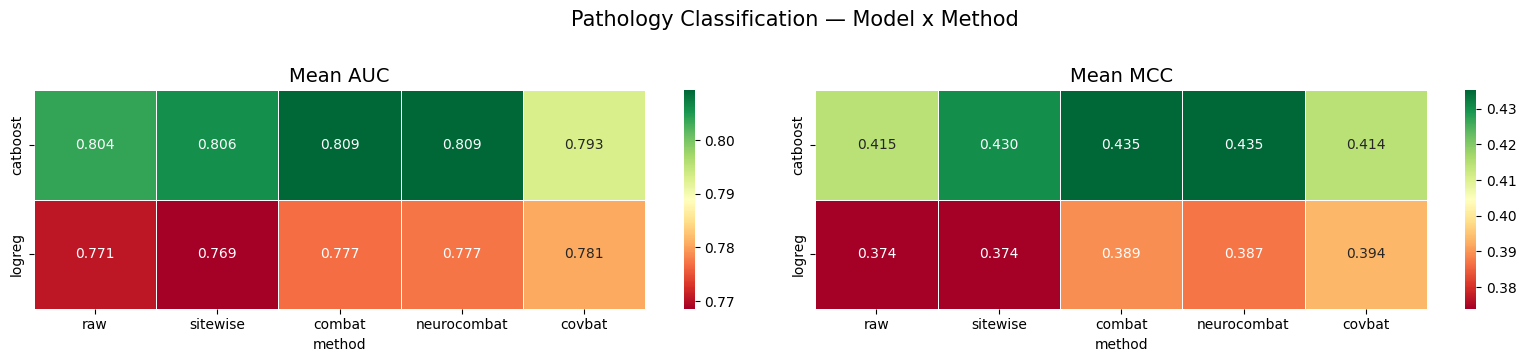

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 3.5))

for ax, metric in zip(axes, ['auc', 'mcc']):
    pivot = (
        df.groupby(['model', 'method'])[metric].mean()
        .unstack(level='method')
        .reindex(columns=METHODS)
    )
    cmap = 'RdYlGn' if metric == 'auc' else 'RdYlGn'
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                linewidths=0.5)
    ax.set_title(f'Mean {metric.upper()}', fontsize=14)
    ax.set_ylabel('')

fig.suptitle('Pathology Classification — Model x Method', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_heatmap_auc_mcc.png', dpi=150, bbox_inches='tight')
plt.show()

## Bar Chart — Mean AUC per Method (grouped by model)

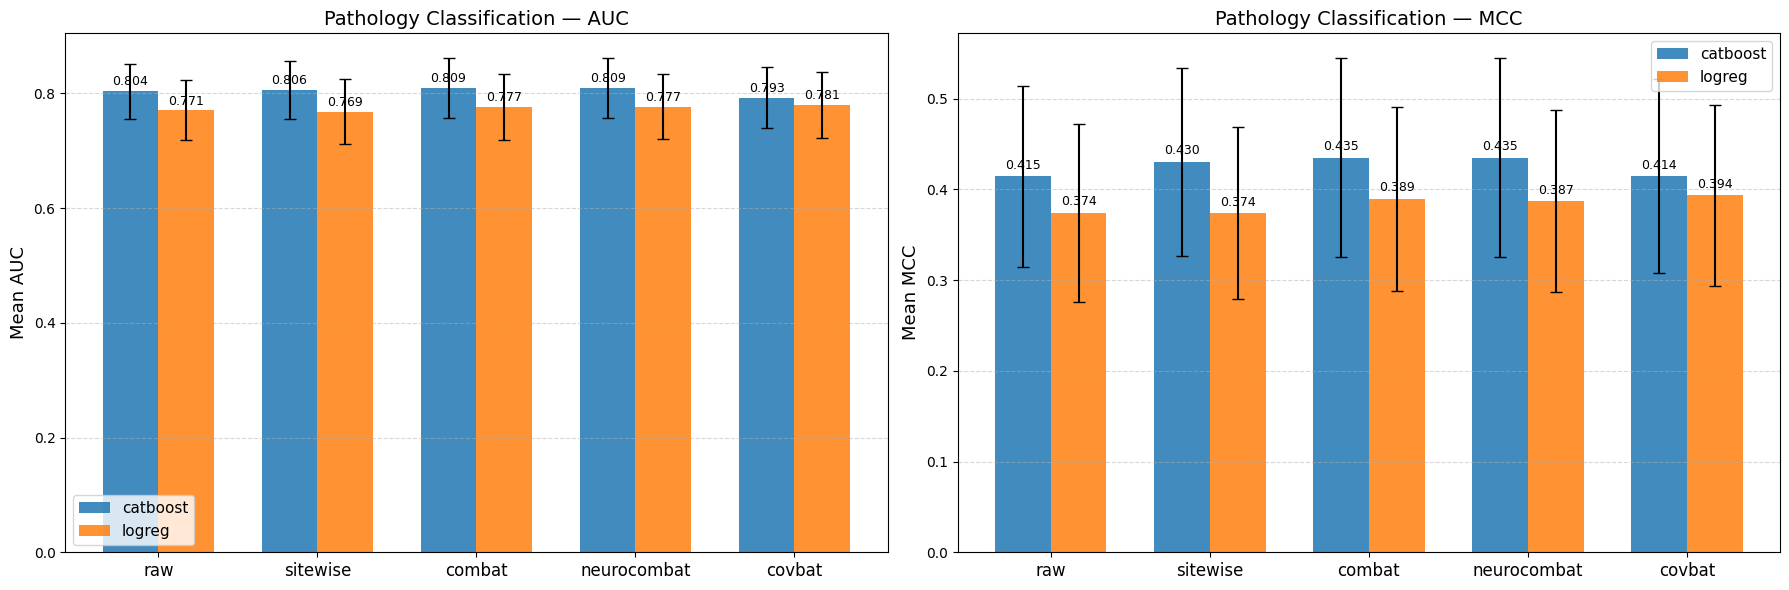

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric in zip(axes, ['auc', 'mcc']):
    x = np.arange(len(METHODS))
    width = 0.35

    for i, model in enumerate(MODELS):
        model_data = df[df['model'] == model].groupby('method')[metric].agg(['mean', 'std']).reindex(METHODS)
        bars = ax.bar(x + i * width, model_data['mean'], width,
                      yerr=model_data['std'], capsize=4,
                      label=model, alpha=0.85)
        for bar, val in zip(bars, model_data['mean']):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(f'Mean {metric.upper()}', fontsize=13)
    ax.set_title(f'Pathology Classification — {metric.upper()}', fontsize=14)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(METHODS, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_bar_auc_mcc.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Hospital AUC — by Method

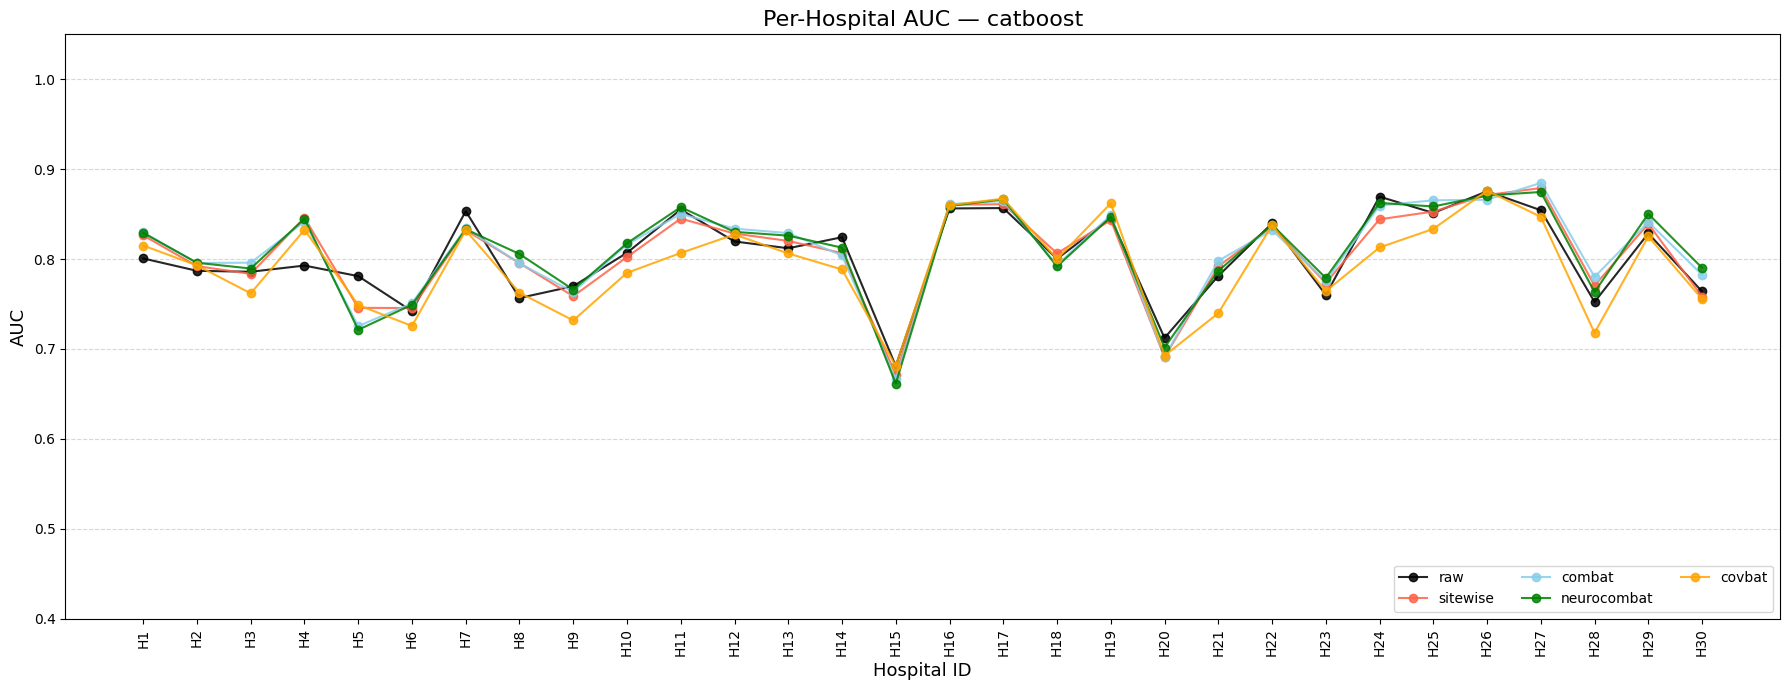

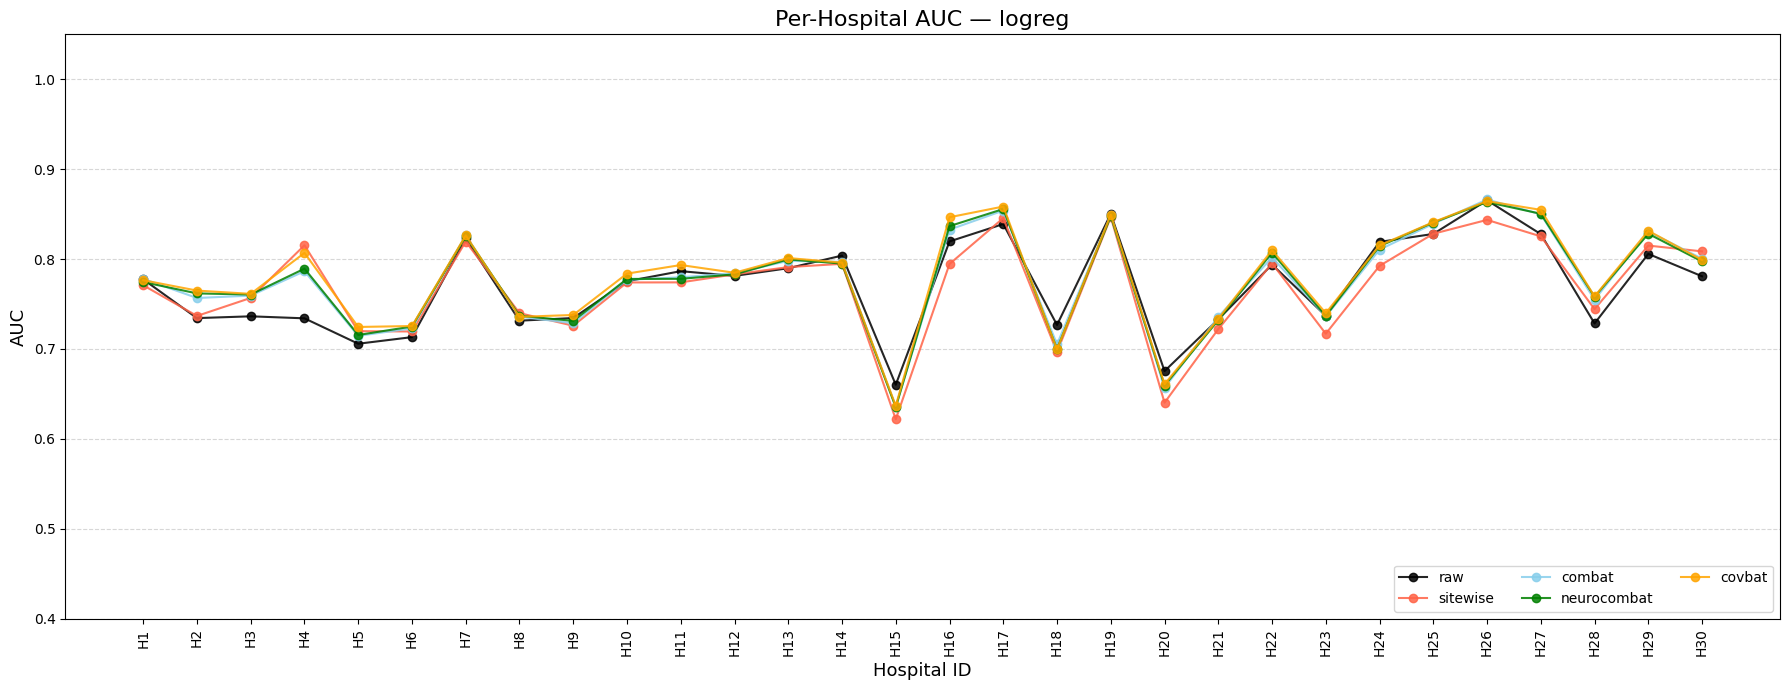

In [7]:
for model in MODELS:
    model_df = df[df['model'] == model]
    if model_df.empty:
        print(f"No results for {model}, skipping.")
        continue

    pivot = model_df.pivot_table(index='method', columns='hospital', values='auc')

    # Sort hospitals naturally: H1, H2, ..., H30
    hospitals_sorted = sorted(pivot.columns, key=natural_sort_key)

    fig, ax = plt.subplots(figsize=(18, 7))
    for method in METHODS:
        if method not in pivot.index:
            continue
        values = [pivot.loc[method].get(h, np.nan) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_MAP[method], label=method, alpha=0.85)

    ax.set_title(f'Per-Hospital AUC — {model}', fontsize=16)
    ax.set_ylabel('AUC', fontsize=13)
    ax.set_xlabel('Hospital ID', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0.4, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='lower right', fontsize=10, ncol=3)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/patho_auc_per_hospital_{model}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Hospital Variance — AUC Distribution across Hospitals

/tmp/ipykernel_4142258/3877504222.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='model_method', y='auc', order=order, ax=ax,
/tmp/ipykernel_4142258/3877504222.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


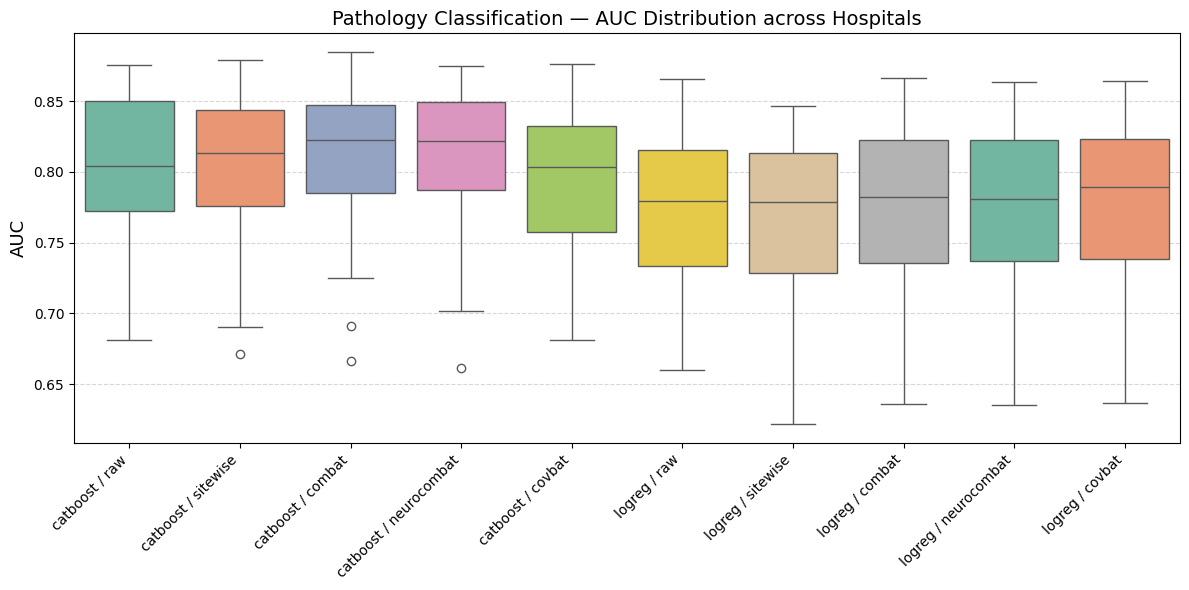

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = df[df['model'].isin(MODELS)].copy()
plot_data['model_method'] = plot_data['model'] + ' / ' + plot_data['method']

order = [f'{m} / {method}' for m in MODELS for method in METHODS
         if not plot_data[(plot_data['model'] == m) & (plot_data['method'] == method)].empty]

sns.boxplot(data=plot_data, x='model_method', y='auc', order=order, ax=ax,
            palette='Set2')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('AUC', fontsize=13)
ax.set_xlabel('')
ax.set_title('Pathology Classification — AUC Distribution across Hospitals', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_auc_hospital_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration Analysis — AUC vs. Test Set Size

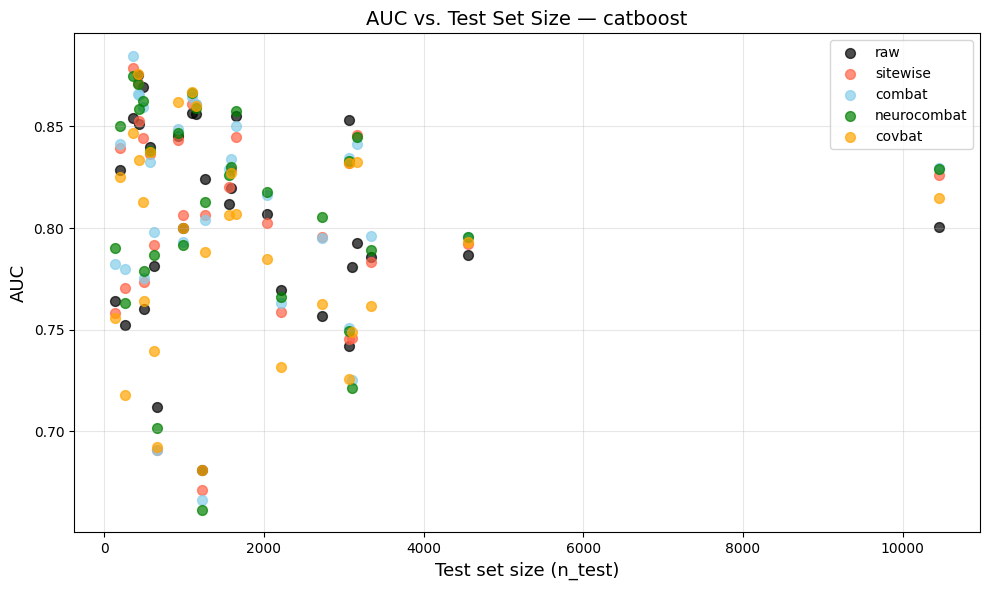

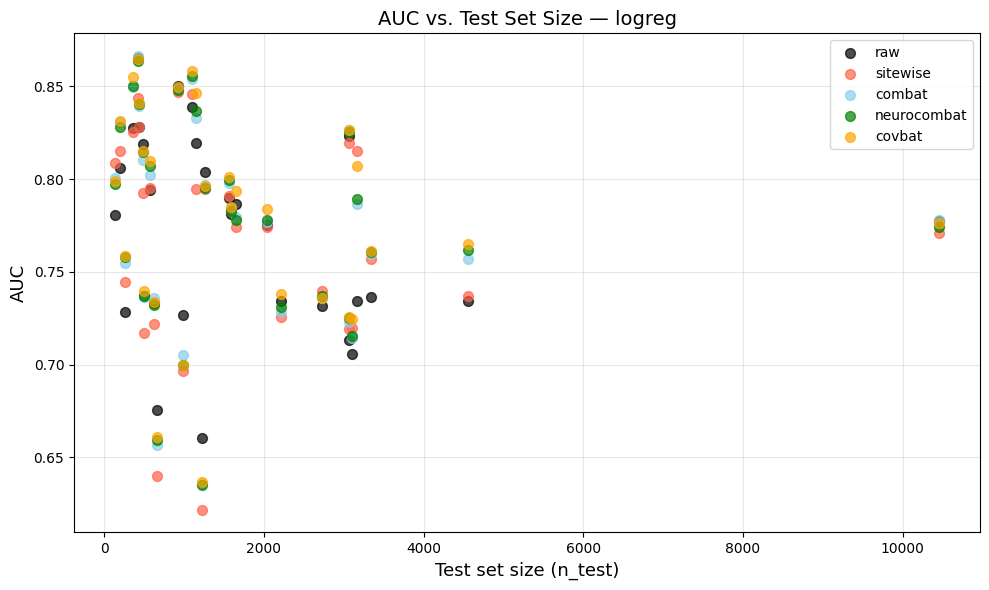

In [9]:
for model in MODELS:
    model_df = df[df['model'] == model]
    if model_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for method in METHODS:
        mdf = model_df[model_df['method'] == method]
        if mdf.empty:
            continue
        ax.scatter(mdf['n_test'], mdf['auc'],
                   color=COLOR_MAP[method], label=method, alpha=0.7, s=50)

    ax.set_xlabel('Test set size (n_test)', fontsize=13)
    ax.set_ylabel('AUC', fontsize=13)
    ax.set_title(f'AUC vs. Test Set Size — {model}', fontsize=14)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/patho_auc_vs_ntest_{model}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Conclusions

*(Fill in after running)*